In [104]:
import numpy as np
import os
import h5py
import matplotlib.pyplot as plt
import jax.numpy as jnp
from jaxdem.analysis import LagBinsPseudoLog, evaluate_binned
from jaxdem.analysis.kernels import msd_kernel
from jaxdem.analysis.kernels import isf_self_isotropic_kernel, msd_kernel, unwrap_angles_2d, msad_kernel_2d, isf_angular_kernel_2d
import jaxdem as jd

from anim_utils import render

def load_arrs(path):
    with h5py.File(path, 'r') as f:
        return {name: f[name][()] for name in f.keys()}

def get_relaxation_time(f, t):
    tau = np.interp(1 / np.e, f[::-1], t[::-1])
    if not np.min(f) < 1 / np.e:
        return np.nan
    return tau

def get_diffusion_coeff(m, t, dim=2, scale=1):
    mask = t < t.max() / (10 * scale)
    c = np.mean(np.log10(m) - np.log10(t))
    return (10 ** c) / (2 * dim)

def quaternion_to_orientation(q_w, q_xyz, ref=None):
    """(T, N, 1), (T, N, 3) -> (T, N, 3)"""
    if ref is None:
        ref = jnp.array([0.0, 0.0, 1.0])
    T = jnp.cross(q_xyz, ref)
    B = jnp.cross(q_xyz, T)
    return ref + 2.0 * (q_w * T + B)

def c1_kernel(arrays, t0, t1):
    """C_1(t) = <e(t0) . e(t1)>"""
    e0 = arrays["orientation"][t0]
    e1 = arrays["orientation"][t1]
    cos_theta = jnp.sum(e0 * e1, axis=-1)
    return jnp.mean(cos_theta, axis=-1)

def c2_kernel(arrays, t0, t1):
    """C_2(t) = <P_2(e(t0) . e(t1))>"""
    e0 = arrays["orientation"][t0]
    e1 = arrays["orientation"][t1]
    cos_theta = jnp.sum(e0 * e1, axis=-1)
    return jnp.mean(0.5 * (3.0 * cos_theta**2 - 1.0), axis=-1)

def legendre_P(l: int, x):
    """Compute P_l(x) for l >= 0 using recurrence. x can be an array."""
    if l < 0:
        raise ValueError("l must be >= 0")
    if l == 0:
        return jnp.ones_like(x)
    if l == 1:
        return x

    Pkm1 = jnp.ones_like(x)  # P_0
    Pk = x                   # P_1
    for k in range(1, l):
        # k is current order of Pk
        Pkp1 = ((2 * k + 1) * x * Pk - k * Pkm1) / (k + 1)
        Pkm1, Pk = Pk, Pkp1
    return Pk

def cl_kernel(arrays, t0, t1, l: int):
    """C_l(t) = < P_l(e(t0) · e(t1)) >.
    arrays[key][t] is shape (N, d) with d=2 or 3; returns scalar.
    """
    e0 = arrays["orientation"][t0]
    e1 = arrays["orientation"][t1]
    cos_theta = jnp.sum(e0 * e1, axis=-1)  # shape (N,)
    return jnp.mean(legendre_P(l, cos_theta), axis=0)

root = '/Users/marshallmccraw/Projects/yale/data/s-26/grant/server-data/test-correlations/'

In [ ]:
for which in os.listdir(root):
    if '.' in which:
        continue
    for phi in os.listdir(os.path.join(root, which)):
        break
    data_root = os.path.join(root, which, phi)
    state = jd.utils.h5.load(os.path.join(data_root, 'init', 'state.h5'))
    system = jd.utils.h5.load(os.path.join(data_root, 'init', 'system.h5'))
    render(state, system, f'{which}.png')

Running preprocessing on config.h5...
Metadata: 2 23.484451 23.484451
Running rendering -> 100_30.png...
Saved rendering to 100_30.png
Success.
Running preprocessing on config.h5...
Metadata: 2 32.93893 32.93893
Running rendering -> 050_12.png...
Saved rendering to 050_12.png
Success.


In [33]:
n_dynamics_steps = 10_000_000
dt = 1e-2
min_save_decade = 100
reset_save_decade = 100_000

save_steps = jnp.asarray(jd.utils.make_save_steps_pseudolog(
    num_steps=n_dynamics_steps,
    reset_save_decade=reset_save_decade,
    min_save_decade=min_save_decade,
    decade=10,
    include_step0=True,
))

T = save_steps.shape[0]
bins = LagBinsPseudoLog(
    T,
    dt_min=1,
    dt_max=int(save_steps[-1] - save_steps[0]),
    timestep=save_steps,
)
tau_steps = bins.values()
t = tau_steps * float(system.dt)

# The new method for calculating the AISF agrees with the old method when the angular period is set as 2 * pi.  However, can we use a smaller angular period?

050_12


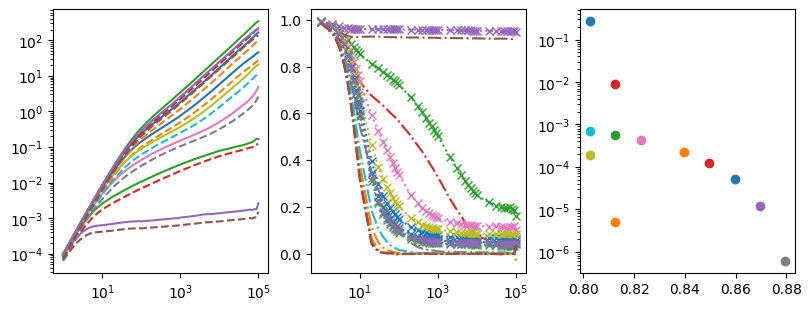

100_30


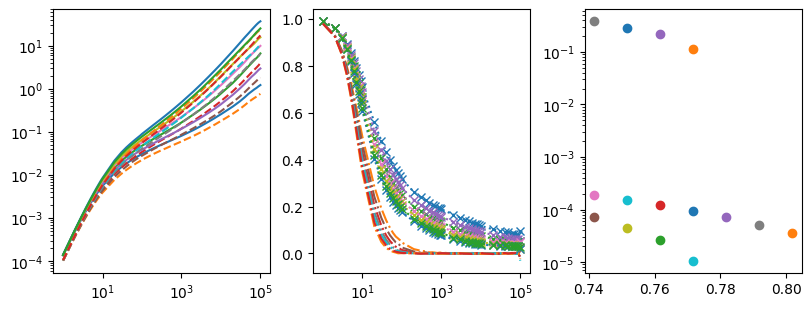

In [113]:
for which in os.listdir(root)[::-1]:
    if '.DS_Store' in which:
        continue
    print(which)
    fig, ax = plt.subplots(1, 3, figsize=(8, 3), constrained_layout=True)
    for phi in os.listdir(os.path.join(root, which)):
        if '.DS_Store' in phi:
            continue
        data_root = os.path.join(root, which, phi)

        data = load_arrs(os.path.join(data_root, 'traj', 'data.h5'))

        q_w = data['q_w']
        q_xyz = data['q_xyz']

        e_major = quaternion_to_orientation(q_w, q_xyz, ref=jnp.array([0.0, 1.0, 0.0]))
        e_minor = quaternion_to_orientation(q_w, q_xyz, ref=jnp.array([1.0, 0.0, 0.0]))

        c1_major = evaluate_binned(c1_kernel, {"orientation": e_major}, bins).mean
        c1_tau = get_relaxation_time(c1_major, t)  # exp(-2 D_r t)
        c1_D_r = 1 / (2 * c1_tau)

        c2_major = evaluate_binned(c2_kernel, {"orientation": e_major}, bins).mean
        c2_tau = get_relaxation_time(c2_major, t)  # exp(-6 D_r t)
        c2_D_r = 1 / (2 * c2_tau)

        cl_major = evaluate_binned(cl_kernel, {"orientation": e_major}, bins, kernel_kwargs={"l": 20}).mean
        cl_tau = get_relaxation_time(c2_major, t)  # exp(-6 D_r t)
        cl_D_r = 1 / (2 * cl_tau)


        ax[0].plot(t, data['msad_small'])
        # ax[1].plot(t, c1_major)
        # ax[1].plot(t, c2_major, ls=':')
        ax[1].plot(t, cl_major, ls=':', marker='x')


        theta = unwrap_angles_2d(q_w, q_xyz)
        theta_0 = 2 * np.pi / (2 * np.pi)
        # theta_0 = 2 * np.pi / (2 * np.pi / nv) -> nv
        # we were doing F=<cos(nv \theta)> - treating nv as the number
        # we need to use the higher order correlators
        msad = evaluate_binned(msad_kernel_2d, {"theta": theta}, bins).mean
        aisf = evaluate_binned(isf_angular_kernel_2d,{"theta": theta}, bins, kernel_kwargs={"theta_0": theta_0}).mean
        aisf_2 = evaluate_binned(isf_angular_kernel_2d,{"theta": theta}, bins, kernel_kwargs={"theta_0": 20 * theta_0}).mean

        D_r = get_diffusion_coeff(msad, t, dim=1)
        
        ax[0].plot(t, msad, ls='--')
        # ax[1].plot(t, aisf, ls='--')
        ax[1].plot(t, aisf_2, ls='-.')

        phi = float(phi.split('phi-')[-1])
        ax[2].scatter(phi, c2_D_r)
        ax[2].scatter(phi, D_r)
        ax[2].scatter(phi, c2_D_r / D_r)
    for a in ax[:-1]:
        a.set_xscale('log')
    ax[0].set_yscale('log')
    ax[2].set_yscale('log')
    plt.show()

In [ ]:
data = load_arrs(os.path.join(data_root, 'traj', 'data.h5'))

n = 100

q_w = data['q_w']
q_xyz = data['q_xyz']

e_major = quaternion_to_orientation(q_w, q_xyz, ref=jnp.array([0.0, 1.0, 0.0]))
e_minor = quaternion_to_orientation(q_w, q_xyz, ref=jnp.array([1.0, 0.0, 0.0]))

c1_major = evaluate_binned(c1_kernel, {"orientation": e_major}, bins).mean

c2_major = evaluate_binned(c2_kernel, {"orientation": e_major}, bins).mean

cl_major = evaluate_binned(cl_kernel, {"orientation": e_major}, bins, kernel_kwargs={"l": n}).mean

theta = unwrap_angles_2d(q_w, q_xyz)
theta_0 = 2 * np.pi / (2 * np.pi / n)
aisf = evaluate_binned(isf_angular_kernel_2d,{"theta": theta}, bins, kernel_kwargs={"theta_0": theta_0}).mean

plt.plot(t, aisf, label='Old')
plt.plot(t, cl_major, label=r'$C_l$')
plt.plot(t, c1_major, label=r'$C_1$')
plt.plot(t, c2_major, label=r'$C_2$')
plt.legend()
plt.xscale('log')